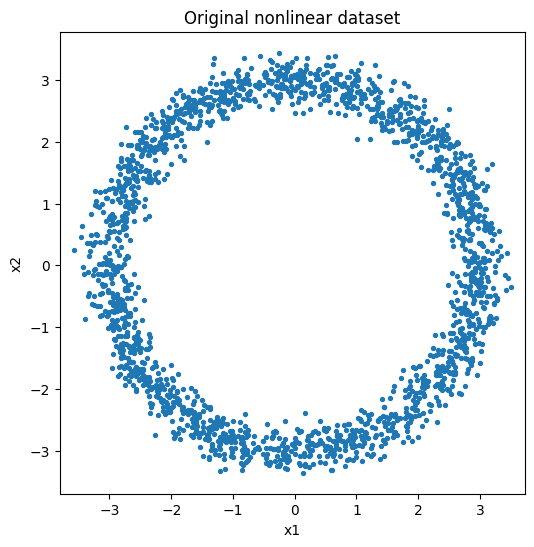

Epoch    0 | Total: 4.6330 | Recon: 4.5341 | KL: 0.0989
Epoch  100 | Total: 2.7285 | Recon: 1.4033 | KL: 1.3252
Epoch  200 | Total: 2.3167 | Recon: 0.8370 | KL: 1.4797
Epoch  300 | Total: 2.2823 | Recon: 0.8127 | KL: 1.4695
Epoch  400 | Total: 2.2381 | Recon: 0.7788 | KL: 1.4594
Epoch  500 | Total: 2.2093 | Recon: 0.7402 | KL: 1.4691
Epoch  600 | Total: 2.2043 | Recon: 0.7260 | KL: 1.4784
Epoch  700 | Total: 2.2282 | Recon: 0.7404 | KL: 1.4877
Epoch  800 | Total: 2.1848 | Recon: 0.7060 | KL: 1.4788
Epoch  900 | Total: 2.2167 | Recon: 0.7079 | KL: 1.5088
Epoch 1000 | Total: 2.1966 | Recon: 0.6896 | KL: 1.5070


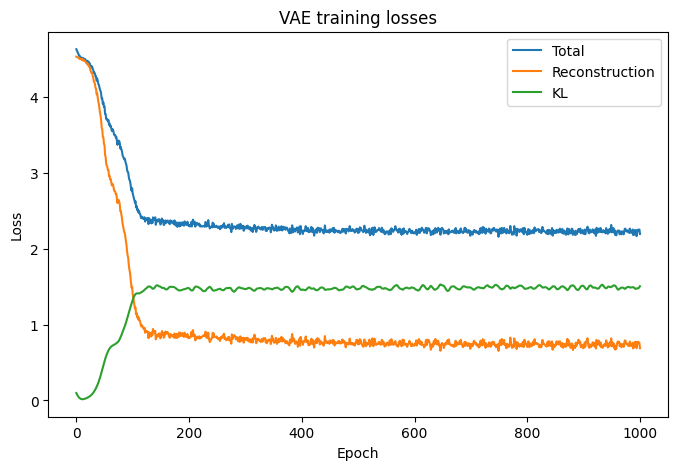

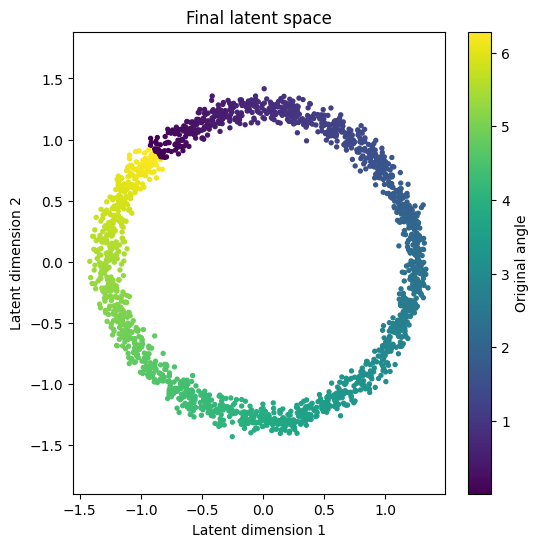

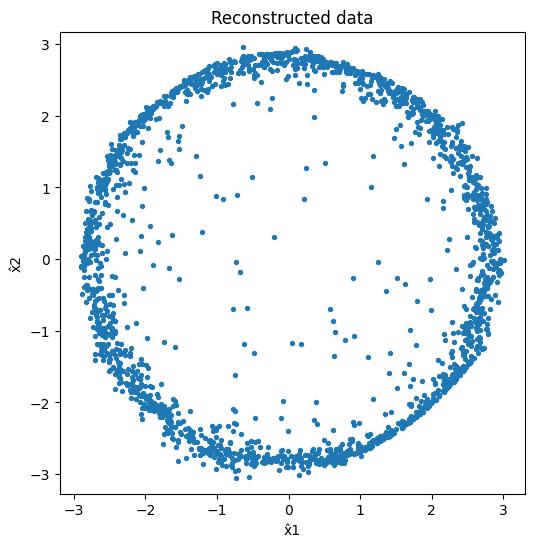

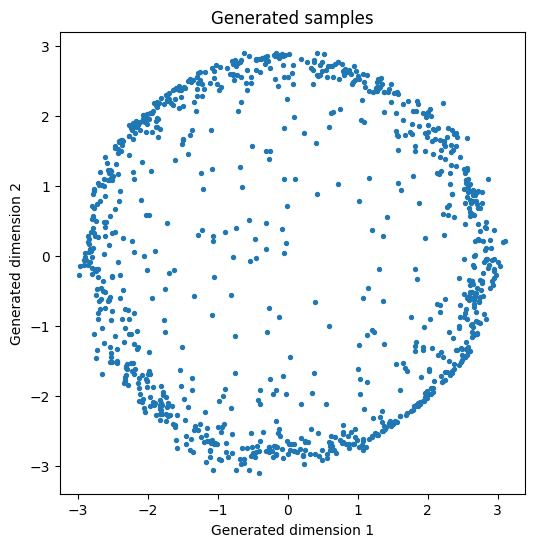


========== Example 0 ==========
x        : tensor([ 2.0693, -1.8884])
mu       : tensor([-1.2238,  0.1268])
logvar   : tensor([-1.3167, -1.6870])
variance : tensor([0.2680, 0.1851])
std      : tensor([0.5177, 0.4302])
z        : tensor([-1.0208, -0.1679])
x_hat    : tensor([ 1.4337, -2.3946])

========== Example 1 ==========
x        : tensor([ 2.5382, -1.5010])
mu       : tensor([-1.2186,  0.3479])
logvar   : tensor([-1.3728, -1.7195])
variance : tensor([0.2534, 0.1792])
std      : tensor([0.5034, 0.4233])
z        : tensor([-0.8451, -0.1537])
x_hat    : tensor([ 1.3886, -2.3392])

========== Example 2 ==========
x        : tensor([-2.0814,  1.8853])
mu       : tensor([ 1.2057, -0.1225])
logvar   : tensor([-1.3606, -1.5992])
variance : tensor([0.2565, 0.2021])
std      : tensor([0.5065, 0.4495])
z        : tensor([1.8647, 0.2812])
x_hat    : tensor([-1.5965,  2.3630])

========== Example 3 ==========
x        : tensor([ 2.7921, -0.7299])
mu       : tensor([-1.0657,  0.6291])
logvar  

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

torch.manual_seed(42)


# ============================================================
# 2. CREATE NONLINEAR RING DATA
# ============================================================

n_samples = 2000

theta = torch.rand(n_samples) * 2 * math.pi

radius = 3.0 + 0.2 * torch.randn(n_samples)

x1 = radius * torch.cos(theta)
x2 = radius * torch.sin(theta)

x = torch.stack([x1, x2], dim=1)


# ============================================================
# 3. VISUALIZE INPUT DATA
# ============================================================

plt.figure(figsize=(6, 6))

plt.scatter(
    x[:, 0],
    x[:, 1],
    s=8
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Original nonlinear dataset")

plt.axis("equal")
plt.show()


# ============================================================
# 4. ENCODER
# ============================================================

class Encoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(2, 32),
            nn.ReLU(),

            nn.Linear(32, 32),
            nn.ReLU(),

            nn.Linear(32, 4)
        )

    def forward(self, x):

        return self.network(x)


# ============================================================
# 5. DECODER
# ============================================================

class Decoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(2, 32),
            nn.ReLU(),

            nn.Linear(32, 32),
            nn.ReLU(),

            nn.Linear(32, 2)
        )

    def forward(self, z):

        return self.network(z)


# ============================================================
# 6. VAE
# ============================================================

class VAE(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = Encoder()
        self.decoder = Decoder()

    def encode(self, x):

        output = self.encoder(x)

        mu = output[:, :2]
        logvar = output[:, 2:]

        return mu, logvar

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5 * logvar)

        epsilon = torch.randn_like(std)

        z = mu + epsilon * std

        return z

    def decode(self, z):

        return self.decoder(z)

    def forward(self, x):

        mu, logvar = self.encode(x)

        z = self.reparameterize(mu, logvar)

        x_hat = self.decode(z)

        return x_hat, mu, logvar, z


# ============================================================
# 7. CREATE MODEL
# ============================================================

model = VAE()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)


# ============================================================
# 8. TRAINING CONFIGURATION
# ============================================================

epochs = 1000

history = {
    "total": [],
    "reconstruction": [],
    "kl": []
}

snapshots = {}

snapshot_epochs = [
    0,
    10,
    50,
    100,
    250,
    500,
    1000
]


# ============================================================
# 9. TRAIN
# ============================================================

for epoch in range(epochs + 1):

    # -------------------------
    # Forward pass
    # -------------------------

    x_hat, mu, logvar, z = model(x)


    # -------------------------
    # Reconstruction loss
    # -------------------------

    reconstruction_loss = F.mse_loss(
        x_hat,
        x
    )


    # -------------------------
    # KL divergence
    # -------------------------

    kl_loss = -0.5 * (
        1
        + logvar
        - mu.pow(2)
        - logvar.exp()
    )

    kl_loss = kl_loss.sum(dim=1).mean()


    # -------------------------
    # Total loss
    # -------------------------

    loss = (
        reconstruction_loss
        + kl_loss
    )


    # -------------------------
    # Backpropagation
    # -------------------------

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()


    # -------------------------
    # Save losses
    # -------------------------

    history["total"].append(
        loss.item()
    )

    history["reconstruction"].append(
        reconstruction_loss.item()
    )

    history["kl"].append(
        kl_loss.item()
    )


    # -------------------------
    # Save latent snapshots
    # -------------------------

    if epoch in snapshot_epochs:

        snapshots[epoch] = (
            mu.detach().clone()
        )


    # -------------------------
    # Print progress
    # -------------------------

    if epoch % 100 == 0:

        print(
            f"Epoch {epoch:4d} | "
            f"Total: {loss.item():.4f} | "
            f"Recon: {reconstruction_loss.item():.4f} | "
            f"KL: {kl_loss.item():.4f}"
        )


# ============================================================
# 10. PLOT LOSSES
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history["total"],
    label="Total"
)

plt.plot(
    history["reconstruction"],
    label="Reconstruction"
)

plt.plot(
    history["kl"],
    label="KL"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE training losses")
plt.legend()

plt.show()


# ============================================================
# 11. GET FINAL LATENT REPRESENTATION
# ============================================================

with torch.no_grad():

    x_hat, mu, logvar, z = model(x)


# ============================================================
# 12. PLOT FINAL LATENT SPACE
# ============================================================

plt.figure(figsize=(6, 6))

plt.scatter(
    mu[:, 0],
    mu[:, 1],
    c=theta,
    s=8
)

plt.xlabel("Latent dimension 1")
plt.ylabel("Latent dimension 2")

plt.title(
    "Final latent space"
)

plt.axis("equal")

plt.colorbar(
    label="Original angle"
)

plt.show()


# ============================================================
# 13. RECONSTRUCTION
# ============================================================

plt.figure(figsize=(6, 6))

plt.scatter(
    x_hat[:, 0],
    x_hat[:, 1],
    s=8
)

plt.xlabel("x̂1")
plt.ylabel("x̂2")

plt.title(
    "Reconstructed data"
)

plt.axis("equal")

plt.show()


# ============================================================
# 14. GENERATE NEW DATA
# ============================================================

z_random = torch.randn(
    1000,
    2
)

with torch.no_grad():

    generated = model.decoder(
        z_random
    )


# ============================================================
# 15. PLOT GENERATED DATA
# ============================================================

plt.figure(figsize=(6, 6))

plt.scatter(
    generated[:, 0],
    generated[:, 1],
    s=8
)

plt.xlabel("Generated dimension 1")
plt.ylabel("Generated dimension 2")

plt.title(
    "Generated samples"
)

plt.axis("equal")

plt.show()


# ============================================================
# 16. INSPECT INDIVIDUAL VALUES
# ============================================================

for i in range(5):

    variance = torch.exp(
        logvar[i]
    )

    std = torch.exp(
        0.5 * logvar[i]
    )

    print(f"\n========== Example {i} ==========")

    print("x        :", x[i])
    print("mu       :", mu[i])
    print("logvar   :", logvar[i])
    print("variance :", variance)
    print("std      :", std)
    print("z        :", z[i])
    print("x_hat    :", x_hat[i])